# Aplicação de Multi-layer Perceptron à séries temporais variantes no tempo

Dataset

Qual o objetivo?

Quais são as técnicas para separação dos dados? (Validação cruzada)

Quais os possíveis problemas no treinamento;

Na arquitetura do Modelo, qual a técnica ultizada para a escolha dos hiperparâmetros.

Quais as métricas de validação usadas para avaliar o desempenho do modelo.

## Carregando o _Dataset_

In [1]:
import json
import random
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import requests
import seaborn
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kfold import Kfold
from mlp_multiclass import FFNeuralNetwork, He_, Layer, Neuron, Xavier
from temporal_classification import (classify_temporal_series,
                                     plot_temporal,
                                     plot_real_trajectory,
                                     plot_temporal_classification)

from extraction_data_methods import *
from mlp_multiclass import *

def get_ts(sample):
    ts_ = json.loads(sample['time_series'])
    return pd.DataFrame(ts_)

def plot_ts(data_df, selected_line, marker=True, smoothed=False, step=5):
    ts = pd.DataFrame(json.loads(data_df['time_series'][selected_line]))
    fig = plt.figure(figsize=(10, 4))
    smoothed_ = ' Smoothed' if smoothed else ''
    fig.suptitle(
        ("{cube} {label} [{lng:,.4f}, {lat:,.4f}]{smoothed_} WGS 84 EPSG:4326").format(
            cube=data_df['cube'][selected_line],
            label=data_df['label'][selected_line],
            lng=data_df['longitude'][selected_line],
            lat=data_df['latitude'][selected_line],
            smoothed_=smoothed_
        )
    )
    seaborn.set_theme(style="darkgrid")
    bands = [band for band in list(ts.keys()) if band != 'Index']
    marker_ = 'o' if marker else None
    for band in bands:
        seaborn.lineplot(
            data=ts,
            x="Index",
            y=band,
            label=band,
            markersize=8,
            marker=marker_,
            linestyle='-'
        )
    ax = plt.gca()
    xticks = range(0, len(ts["Index"]), step)
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        ts["Index"].iloc[::step]
    )
    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()
    plt.tight_layout()
    plt.show()

# get bands description
service = pystac_client.Client.open("https://data.inpe.br/bdc/stac/v1/")
collection = service.get_collection('mod13q1-6.1').to_dict()
bands_description = collection['properties']['eo:bands']

# Recuperando a base de dados
samples = pd.read_csv('./samples/samples_mt_time_series.csv')

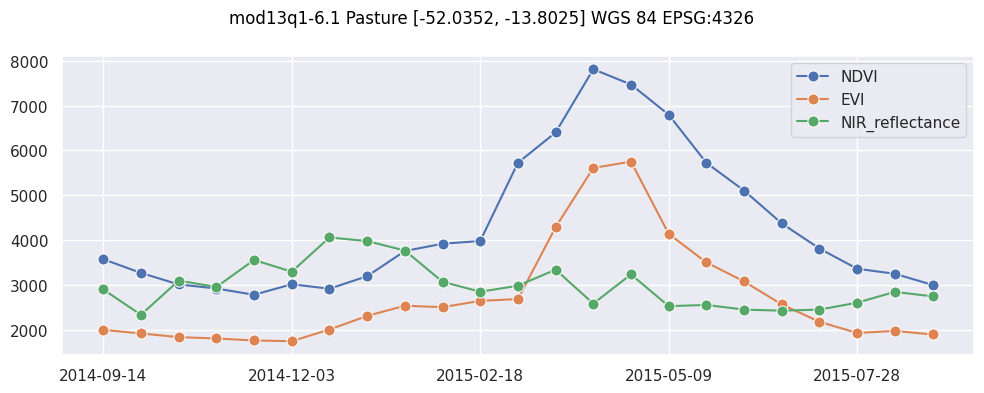

In [2]:
plot_ts(samples, random.randint(0, (len(samples) - 1)))

## Selecionando os atributos

In [3]:
bands = ["NDVI", "EVI", "NIR_reflectance"]
samples = extract_bands(samples, bands)

## Normalização dos valores referente ao satélite

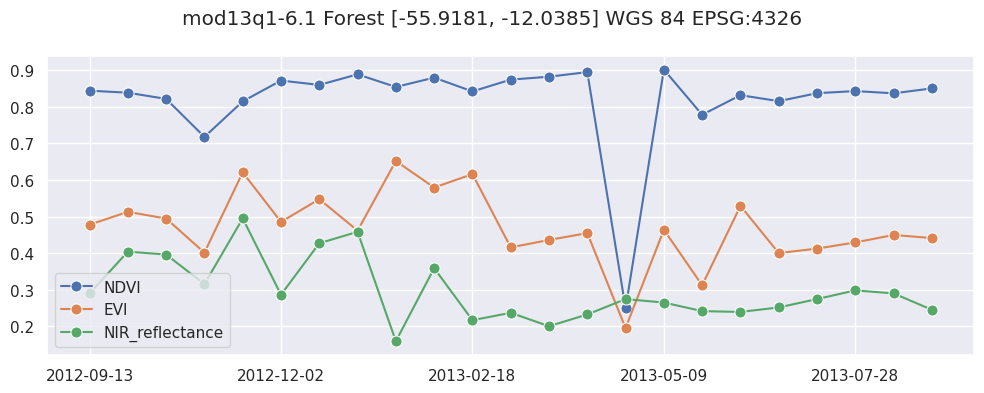

In [4]:
samples_norm = normalize_(samples, bands_description)
plot_ts(samples_norm, random.randint(0, (len(samples_norm) - 1)))

## Interpolação de valores nulos referente ao satélite

In [5]:
samples_inter = interpolate_(samples_norm, bands_description)
samples_inter

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


## Suavização Savitzky Golay para generalizar as features

In [6]:
sgolay = SGolay(7, 3)
samples_smoothed = smooth_(samples_inter, sgolay)
samples_smoothed

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


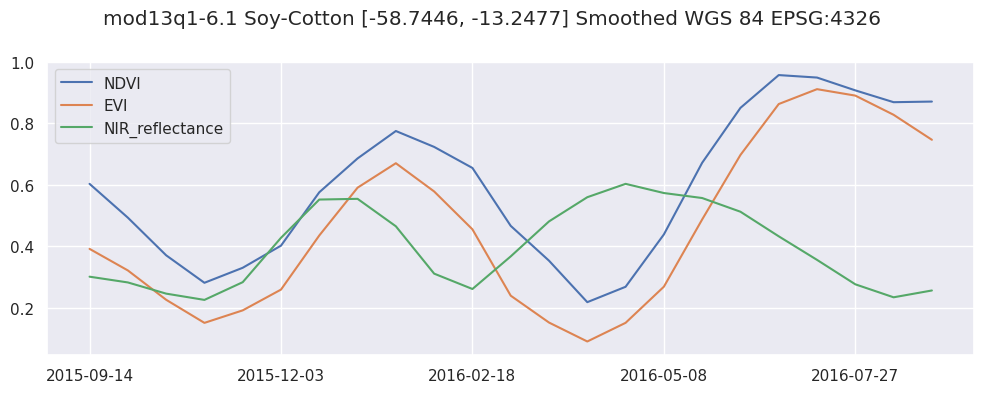

In [7]:
plot_ts(samples_smoothed, random.randint(0, (len(samples_inter) - 1)), marker = False, smoothed=True)

## Verificação simples para ver que as séries estão com os mesmo número de time stamps

In [8]:
def count_ts(samples):
    samples_ = samples.copy()
    count = []
    for row in range(0, len(samples_)):
        count.append(len(json.loads(samples_['time_series'][0])['Index']))
    return count

set(count_ts(samples_smoothed))

{23}

## Análise Exploratória

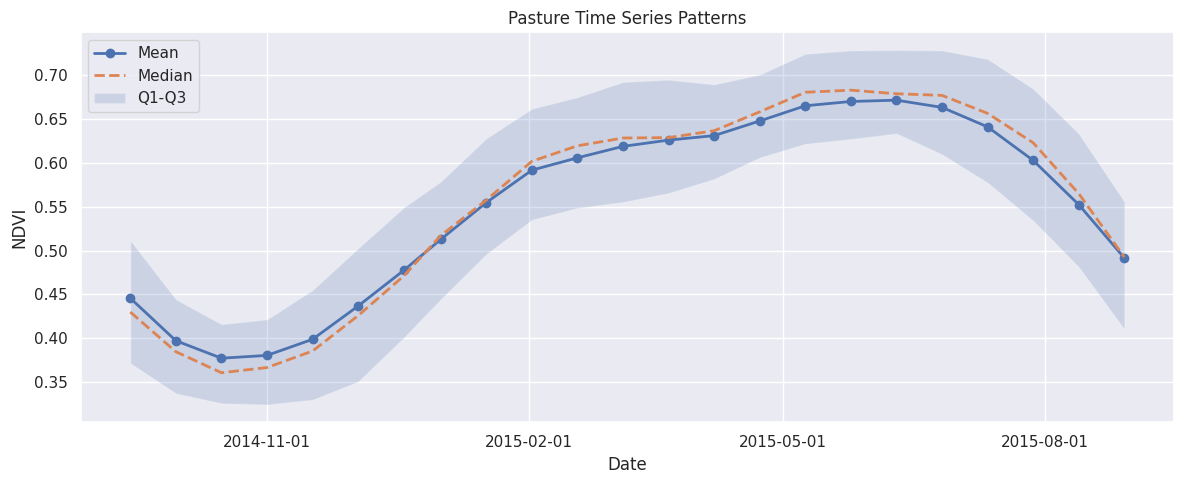

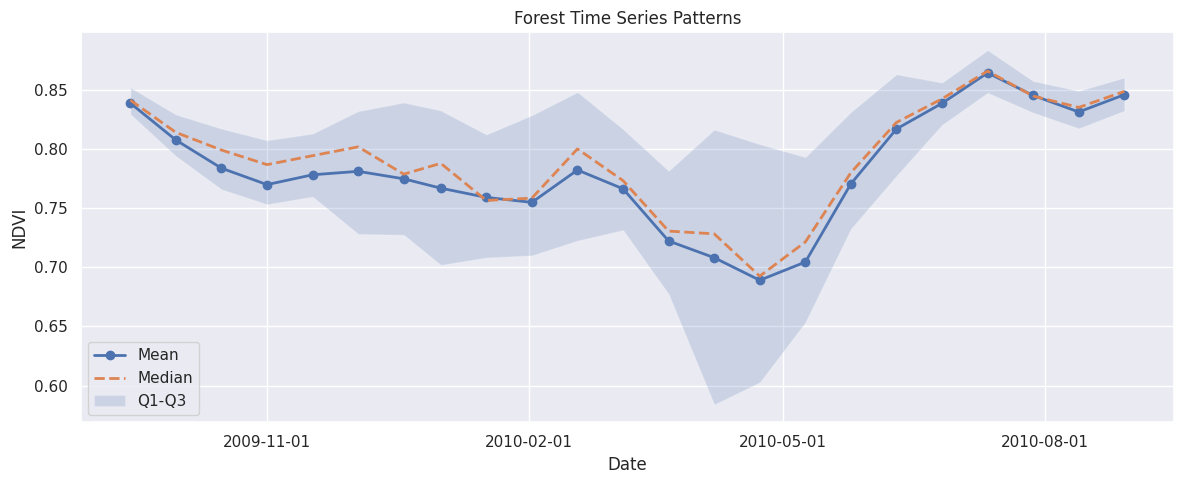

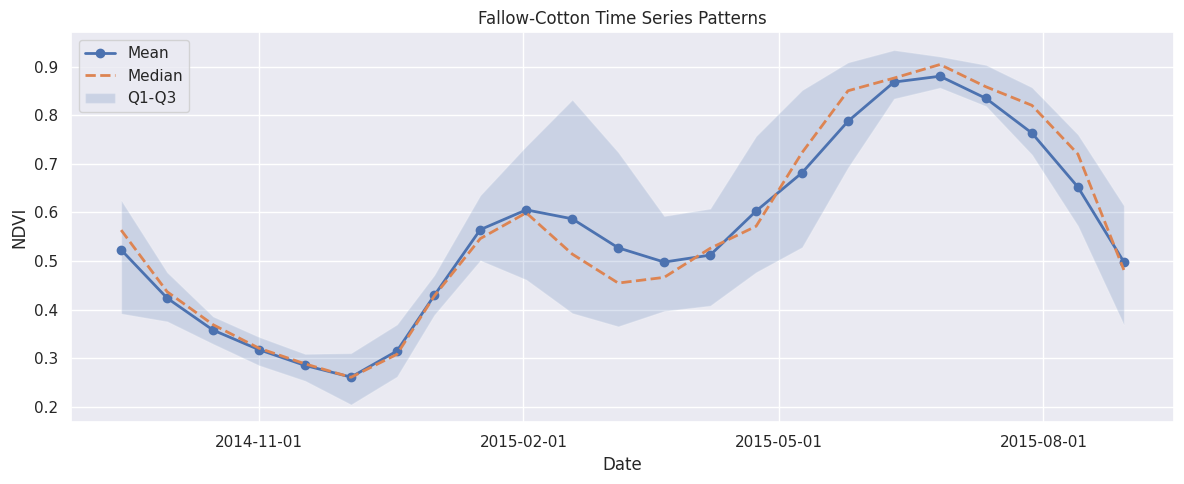

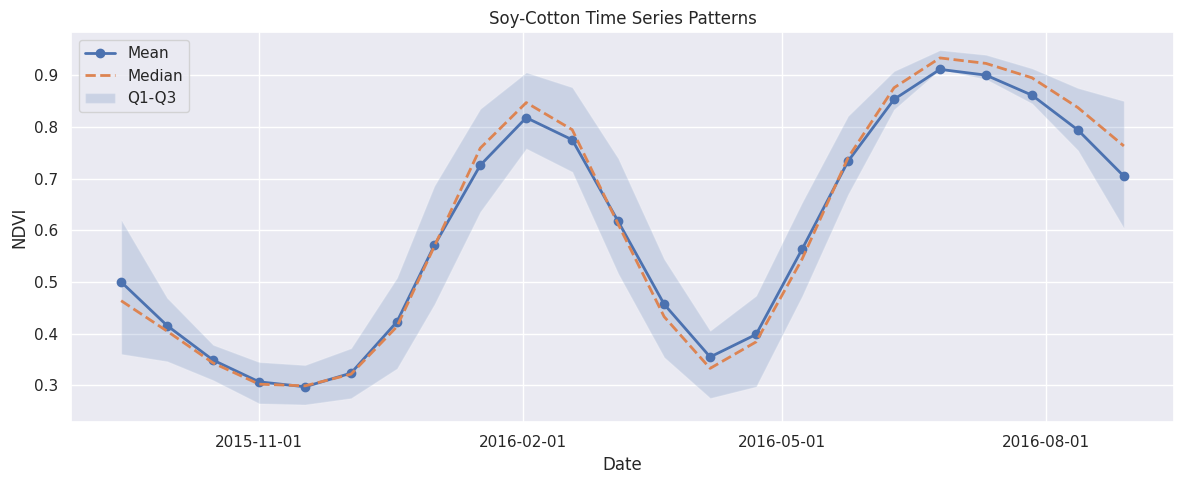

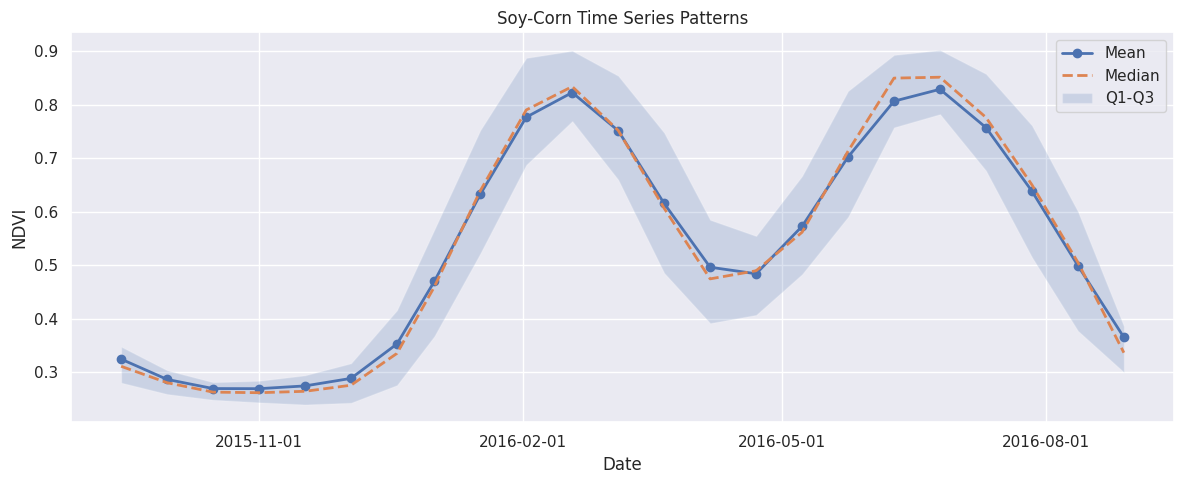

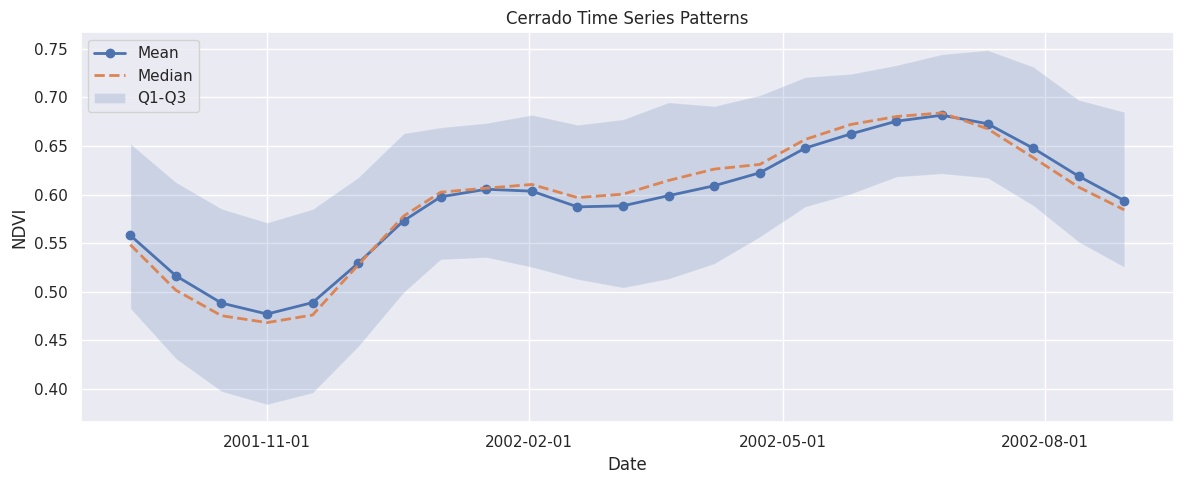

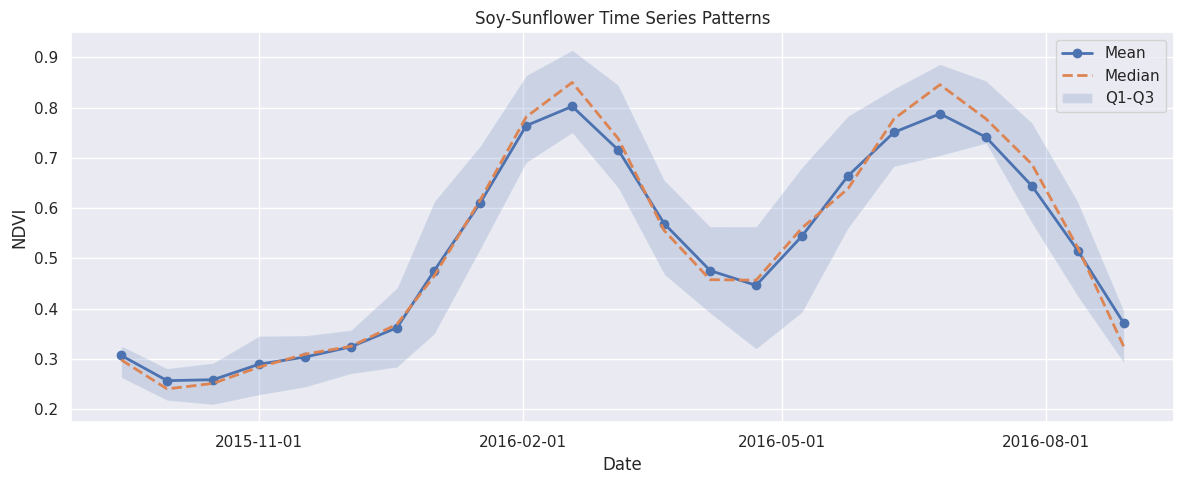

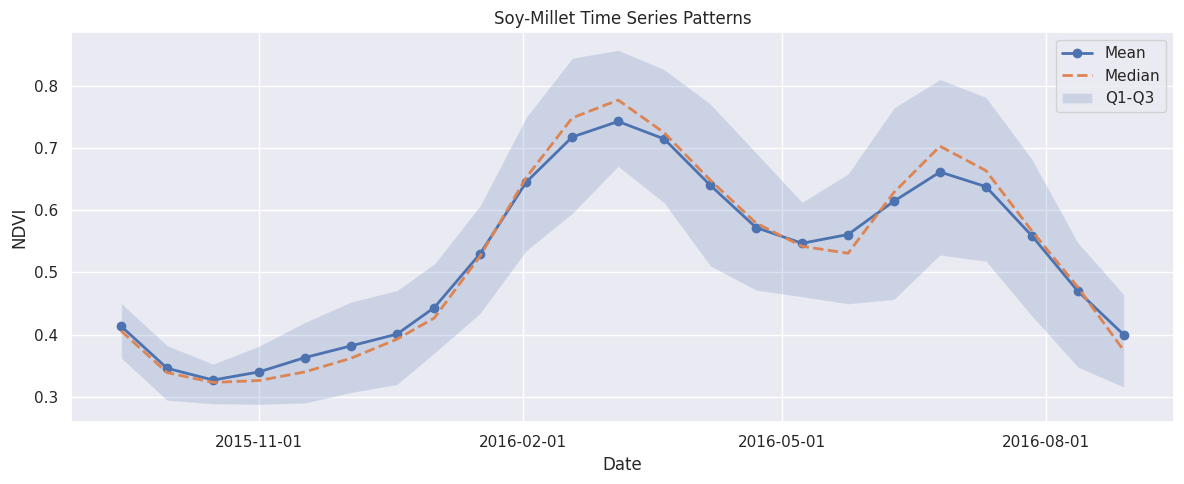

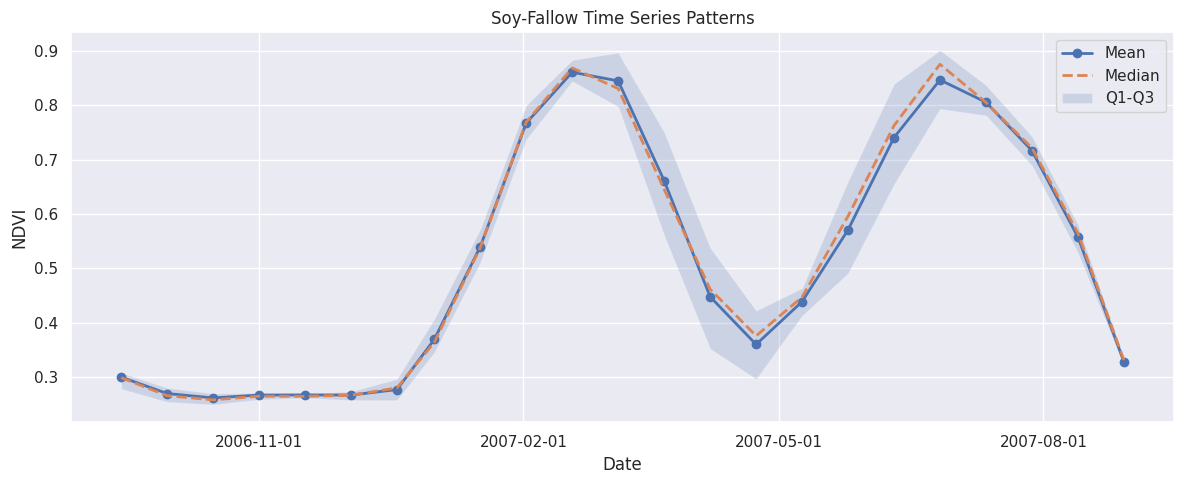

In [9]:
def plot_patterns(samples, band, step=3):

    labels = set(samples['label'])

    for label in labels:

        samples_label = (
            samples[samples['label'] == label]['time_series']
            .reset_index(drop=True)
        )

        all_values = []

        # Read all samples
        for row in range(len(samples_label)):

            df = pd.DataFrame(json.loads(samples_label[row]))

            # Keep only selected band
            values = df[band]

            all_values.append(values)

        # Create matrix:
        # rows = samples
        # cols = timesteps
        only_values = pd.concat(all_values, axis=1).T

        # Statistics
        mean_values = only_values.mean(axis=0)
        median_values = only_values.median(axis=0)

        q1 = only_values.quantile(0.25, axis=0)
        q3 = only_values.quantile(0.75, axis=0)

        # Dates
        indexes = pd.to_datetime(df["Index"])

        # Plot
        fig, ax = plt.subplots(figsize=(12, 5))

        # Mean curve
        ax.plot(
            indexes,
            mean_values,
            marker="o",
            linewidth=2,
            label="Mean"
        )

        # Median curve
        ax.plot(
            indexes,
            median_values,
            linestyle="--",
            linewidth=2,
            label="Median"
        )

        # Quartile interval
        ax.fill_between(
            indexes,
            q1,
            q3,
            alpha=0.2,
            label="Q1-Q3"
        )

        # Labels
        ax.set_title(f"{label} Time Series Patterns")
        ax.set_xlabel("Date")
        ax.set_ylabel(band)

        # Date spacing like your example
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=step))
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter('%Y-%m-%d')
        )

        ax.legend()

        plt.tight_layout()
        plt.show()

plot_patterns(samples_smoothed, "NDVI")

In [10]:
classes = np.unique(samples['label'])
getAllClasses(samples)

,class_name,index,color
0,Cerrado,0,#FF7D66
1,Fallow-Cotton,1,#5480FF
2,Forest,2,#BDBDBD
3,Pasture,3,#698891
4,Soy-Corn,4,#487D5D
5,Soy-Cotton,5,#AB5B96
6,Soy-Fallow,6,#45A2BF
7,Soy-Millet,7,#92D199
8,Soy-Sunflower,8,#92A7D1


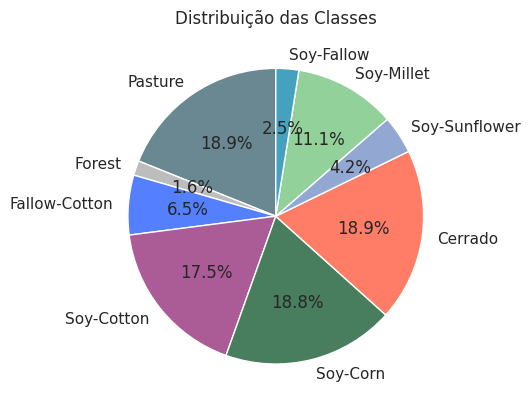

In [11]:
# Contar amostras por classe

def plot_distribution(samples):
    class_counts = pd.Series(list(samples['label'])).value_counts().sort_index()
    
    # Labels (nomes das classes)
    labels = [ str(getClass(samples, label=label_)['class_name'][0]) for label_ in list(set(samples['label'])) ]
    
    colors = [ str(getClass(samples, label=label_)['color'][0]) for label_ in list(set(samples['label'])) ]
    
    # Plotar gráfico de pizza
    plt.figure()
    plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição das Classes')
    
    plt.show()

plot_distribution(samples = samples_smoothed)

## Formatando as séries temporais para a MLP

In [12]:
random_sample = random.randint(0, (len(samples_smoothed) - 1))

original = samples_smoothed['time_series'][random_sample]
flatten = extract_features(original)

label = samples_smoothed['label'][random_sample]
label_code = encode_label(samples, label)

print(f"Original => ({label}): ", original, "\n")
print(f"Flatten => ({label_code}): ", flatten)
print()

Original => (Forest):  {"Index": ["2011-09-14", "2011-09-30", "2011-10-16", "2011-11-01", "2011-11-17", "2011-12-03", "2011-12-19", "2012-01-01", "2012-01-17", "2012-02-02", "2012-02-18", "2012-03-05", "2012-03-21", "2012-04-06", "2012-04-22", "2012-05-08", "2012-05-24", "2012-06-09", "2012-06-25", "2012-07-11", "2012-07-27", "2012-08-12", "2012-08-28"], "NDVI": [0.8311833333333328, 0.8072261904761904, 0.7805976190476192, 0.7584809523809529, 0.7603047619047625, 0.7687714285714291, 0.7225619047619053, 0.7027142857142862, 0.7225428571428576, 0.8181904761904768, 0.7842952380952386, 0.8022571428571434, 0.7307571428571433, 0.7213523809523814, 0.7525619047619052, 0.8295476190476195, 0.7862000000000007, 0.8380047619047625, 0.8532428571428576, 0.8642523809523814, 0.8550952380952385, 0.8393380952380961, 0.8233642857142875], "EVI": [0.5024880952380961, 0.5629309523809531, 0.5377095238095244, 0.4781904761904765, 0.47895714285714314, 0.5000857142857146, 0.47852380952380985, 0.47453809523809554, 0.

## Separação de treino, teste e validação usando _Holdout_

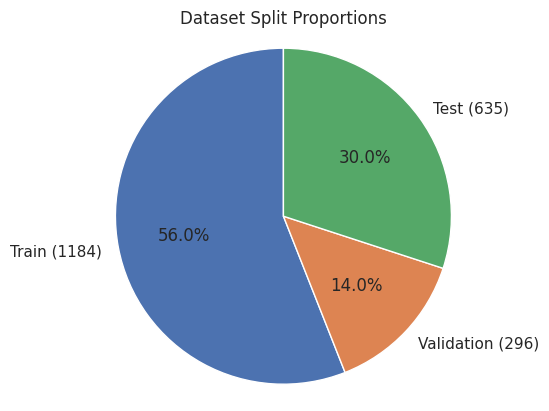

In [13]:
dataset = samples_smoothed.copy()

X = []
y = []

for _, row in dataset.iterrows():
    X.append(extract_features(row["time_series"]))
    y.append(encode_label(samples, row["label"]))

X = np.array(X)
y = np.array(y)

# Example usage with your variables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train = (X_train - X_train.mean(axis=0)) / std_(X_train)
X_val = (X_val - X_val.mean(axis=0)) / std_(X_val)
X_test = (X_test - X_test.mean(axis=0)) / std_(X_test)

# Quantidade de amostras
train_size = len(X_train)
val_size = len(X_val)
test_size = len(X_test)

sizes = [train_size, val_size, test_size]
labels = [
    f"Train ({train_size})",
    f"Validation ({val_size})",
    f"Test ({test_size})"
]
plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Dataset Split Proportions")
plt.axis('equal')
plt.show()

## Arquitetura MLP

Usando regularização L2 para penalizar pesos grandes;

Usando early_stop;

Inicialização dos pesos com _He_;

Epoch 0 | Train Loss: 1.765738 | Val Loss: 1.201389

Early stopping at epoch 43
Best validation loss: 0.407923


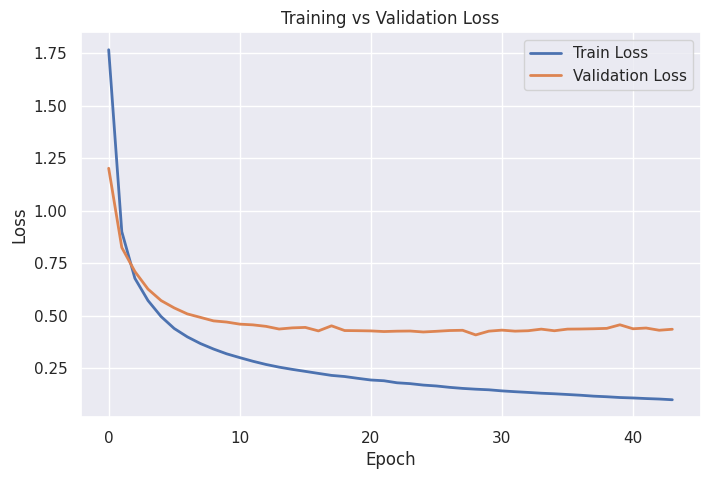

In [14]:
input_size = X.shape[1]

seed = 42

topology = [input_size, 32, 16, 9]

layers = [
    Layer(32, Neuron, relu, d_relu),
    Layer(16, Neuron, relu, d_relu),
    Layer(9, Neuron, softmax, d_softmax, multiclass=True)
]

nn = FFNeuralNetwork(topology, layers, method_init=He_, multiclass = True, lambda_l2=1e-4, rand_seed = seed)

nn.fit_with_validation(X_train, y_train, X_val, y_val, learning_rate=0.001, n_epochs=200, patience = 15)
nn.plot_train_val_loss()

In [ ]:
input_size = X.shape[1]

seed = 42

topology = [input_size, 32, 16, 9]

layers = [
    Layer(32, Neuron, relu, d_relu),
    Layer(16, Neuron, relu, d_relu),
    Layer(9, Neuron, softmax, d_softmax, multiclass=True)
]

nn = FFNeuralNetwork(topology, layers, method_init=He_, multiclass = True, lambda_l2=1e-4, rand_seed = seed)

nn.fit_with_validation(X_train, y_train, X_val, y_val, learning_rate=0.001, n_epochs=200, patience = 15)
nn.plot_train_val_loss()

## Aplicação do conjunto de teste

{'accuracy': 0.9007874015748032, 'precision': 0.891558592143118, 'recall': 0.8338329774647358, 'f1_score': 0.8498601674336566}


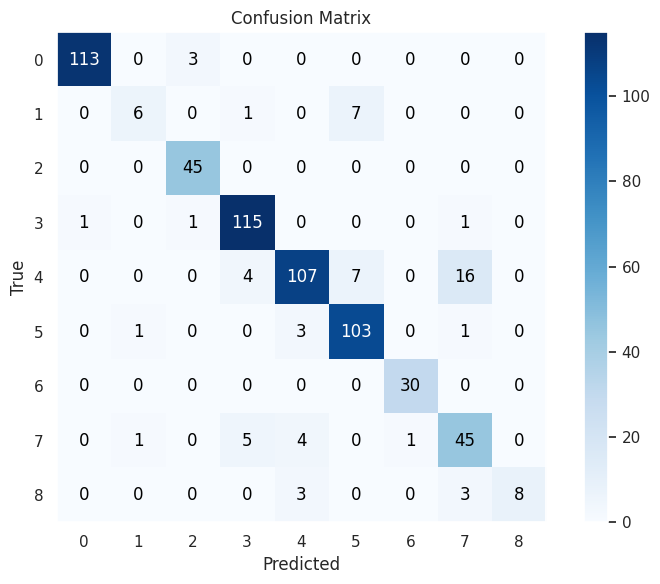

In [15]:
test_results = nn.test(X_test, y_test, threshold=0.6)

print(test_results["metrics"])

# predictions
y_probs, y_preds = nn.predict(X_test)

# plot confusion matrix
nn.plot_confusion_matrix(y_test, y_preds)

## Classificação de série temporal 2000 até agora:

Usando uma janela deslizante de 23 timestamps.

Usando como base de validação o WLTS.

In [16]:
wlts_ = pd.read_csv("./samples/test_samples/[-57.9627287550, -13.4889087095]_wlts_ibge_mapbiomas.csv", sep = ";")
wtss_ = pd.read_csv("./samples/test_samples/[-57.9627287550, -13.4889087095]_wtss_mod13q1.csv")

getAllClassesWLTS(wlts_)

,class_name,index,color
0,Algodão (beta),0,#9BD3E8
1,Soja,1,#C9C285
2,Área Agrícola,2,#C0F279


In [17]:
wtss_ = interpolate_single_ts(wtss_, bands_description)
wtss_ = sgolay.apply_ts(wtss_)
result, y_probs = classify_temporal_series(wtss_, nn, 23, getAllClasses(samples))
result

,Index,EVI,NDVI,NIR_reflectance,pred,label
0,2000-02-18,0.731598,0.744169,0.519071,NaN,NaN
1,2000-03-05,0.302721,0.423207,0.402588,NaN,NaN
2,2000-03-21,0.126264,0.290343,0.315695,NaN,NaN
3,2000-04-06,0.110176,0.274776,0.256810,NaN,NaN
4,2000-04-22,0.158119,0.318105,0.215819,NaN,NaN
...,...,...,...,...,...,...
591,2025-11-01,0.208133,0.349086,0.283495,7.0,Soy-Millet
592,2025-11-17,0.254743,0.392410,0.320714,7.0,Soy-Millet
593,2025-12-03,0.370557,0.515238,0.375560,7.0,Soy-Millet
594,2025-12-19,0.574329,0.707410,0.459267,7.0,Soy-Millet


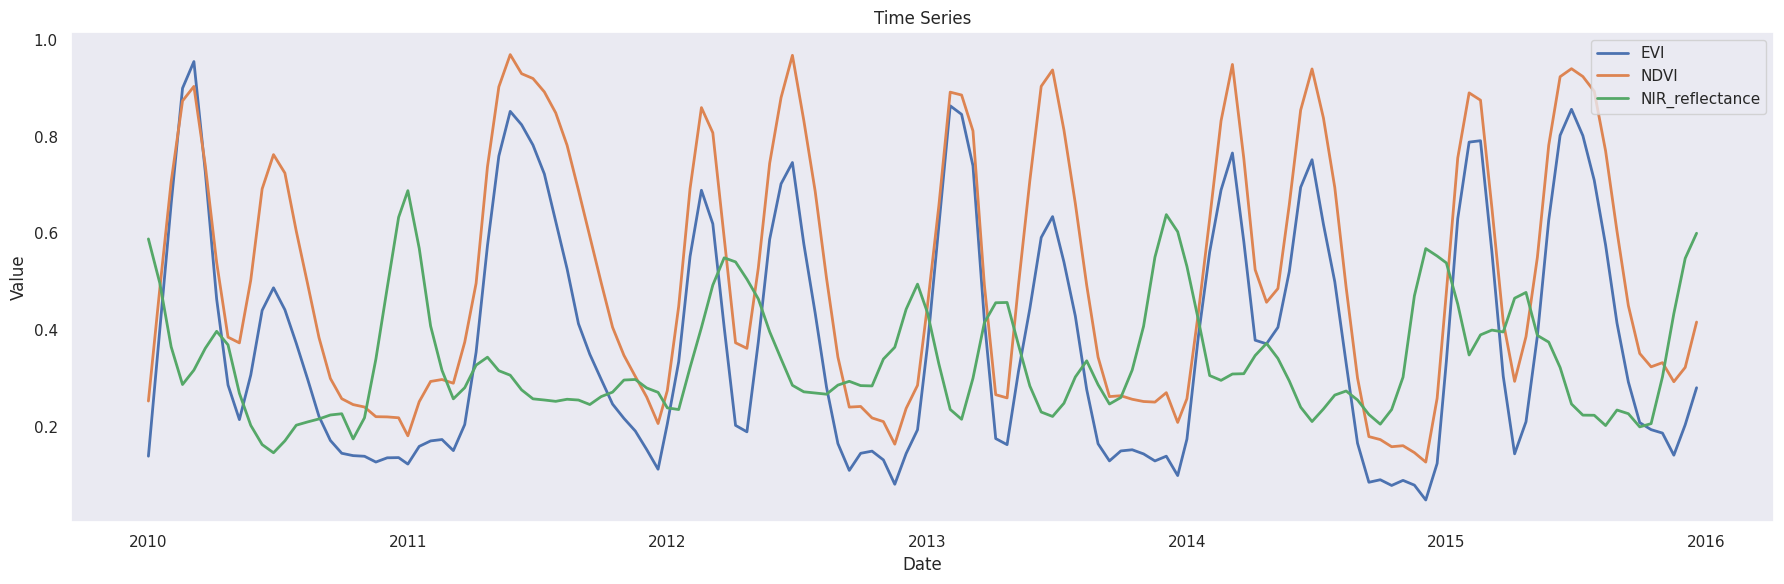

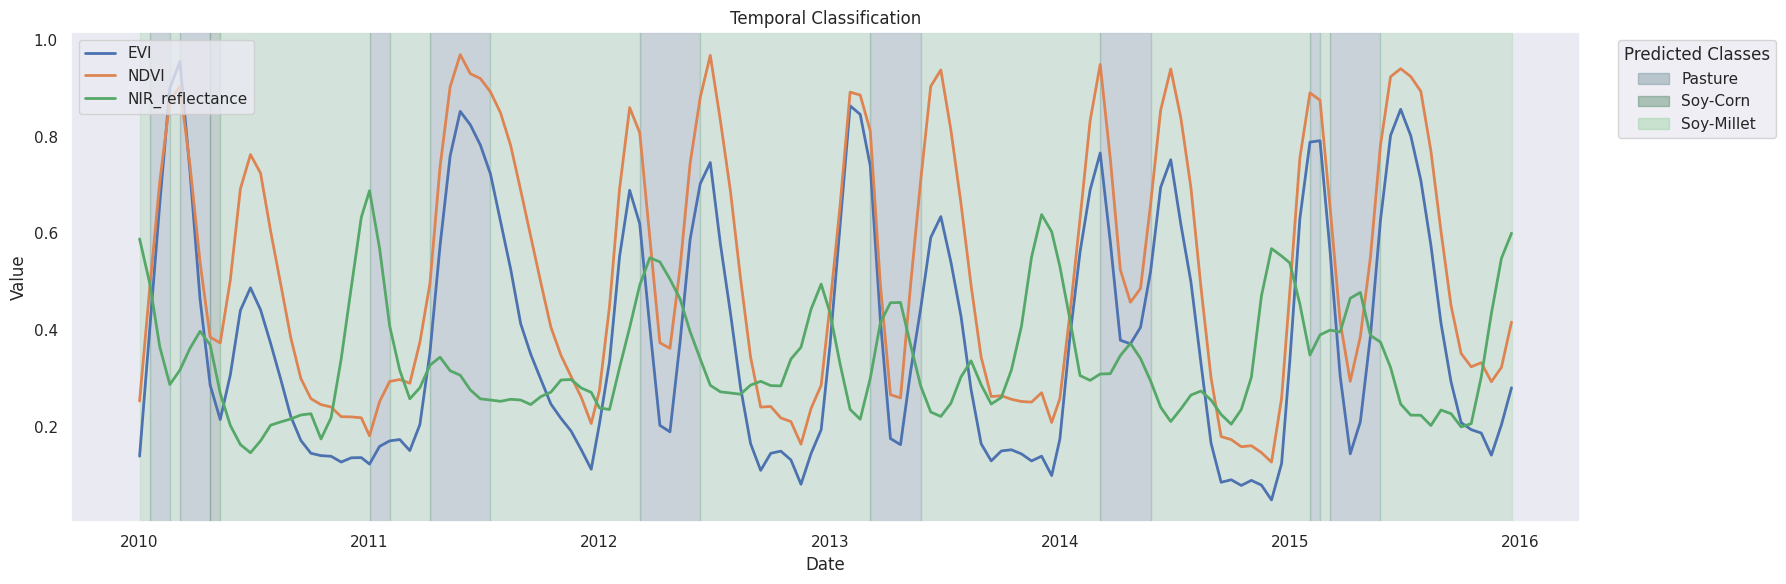

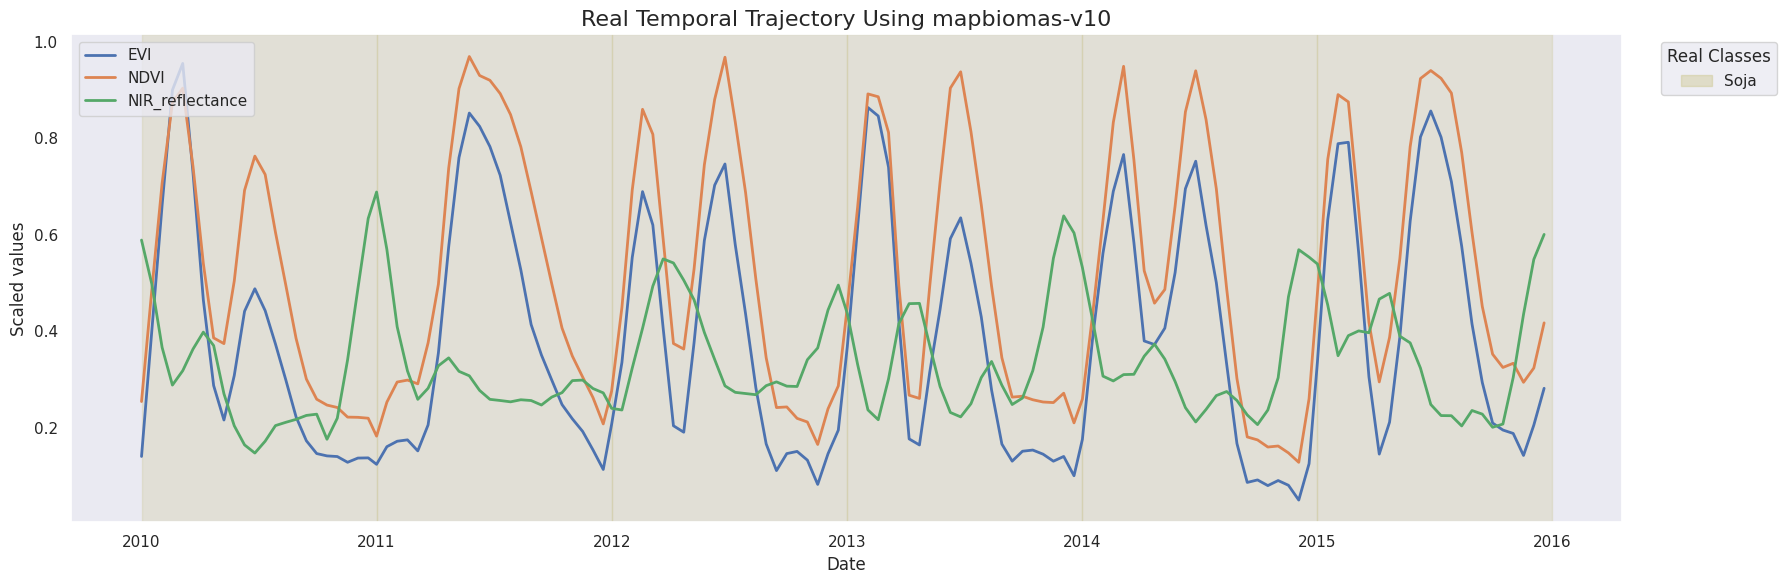

In [19]:
start_date_ = "2010-01-01"
end_date_ = "2015-12-31"

plot_temporal(
    wtss_,
    start_date=start_date_,
    end_date=end_date_
)
plot_temporal_classification(
    result,
    getAllClasses(samples),
    title="Temporal Classification",
    start_date=start_date_,
    end_date=end_date_
)
plot_real_trajectory(
    wtss_, wlts_,
    class_system=getAllClassesWLTS(wlts_),
    start_date=start_date_,
    end_date=end_date_
)